** CAR PRICE ANALYSIS —  Exploratory Data Analysis**

In [78]:
# import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

In [79]:
# load data
df = pd.read_csv("car_price.csv")
df.head()


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [80]:
# ── Shape ─────────────
print(f"\n Rows    : {df.shape[0]:,}")
print(f" Columns : {df.shape[1]}")


 Rows    : 72,435
 Columns : 10


In [81]:
# ──  Feature types ────────────────
numerical_cols   = df.select_dtypes(include=['float64','int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n Numerical features   ({len(numerical_cols)}): {numerical_cols}")
print(f" Categorical features ({len(categorical_cols)}): {categorical_cols}")


 Numerical features   (6): ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
 Categorical features (4): ['model', 'transmission', 'fuelType', 'Make']


In [82]:
# ──  Missing values ─────────────────────────
print("\n\n MISSING VALUES")
print("-" * 40)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df.to_string())
print(f"\n  Total missing cells : {missing.sum():,}")
print(f"  Rows with any null  : {df.isnull().any(axis=1).sum():,}")



 MISSING VALUES
----------------------------------------
              Missing Count  Missing %
model                  3621        5.0
year                   3622        5.0
price                  3621        5.0
transmission           3623        5.0
mileage                3622        5.0
fuelType               3622        5.0
tax                    3621        5.0
mpg                    3621        5.0
engineSize             3622        5.0
Make                   3621        5.0

  Total missing cells : 36,216
  Rows with any null  : 29,110


In [83]:

# ──  preview ──────────────────────────────────────────
print("\n\n📊 PRICE DISTRIBUTION SUMMARY")
print("-" * 40)
print(df['price'].describe().round(2).to_string())

print("\n\n🔗 CORRELATION WITH PRICE (numerical features)")
print("-" * 40)
corr = df[numerical_cols].corr()['price'].drop('price').sort_values(key=abs, ascending=False)
print(corr.round(4).to_string())



📊 PRICE DISTRIBUTION SUMMARY
----------------------------------------
count     68814.00
mean      16583.92
std        9304.41
min         495.00
25%       10167.25
50%       14495.00
75%       20359.75
max      145000.00


🔗 CORRELATION WITH PRICE (numerical features)
----------------------------------------
engineSize    0.6298
year          0.5194
mileage      -0.4275
tax           0.3532
mpg          -0.3356


**visualization**

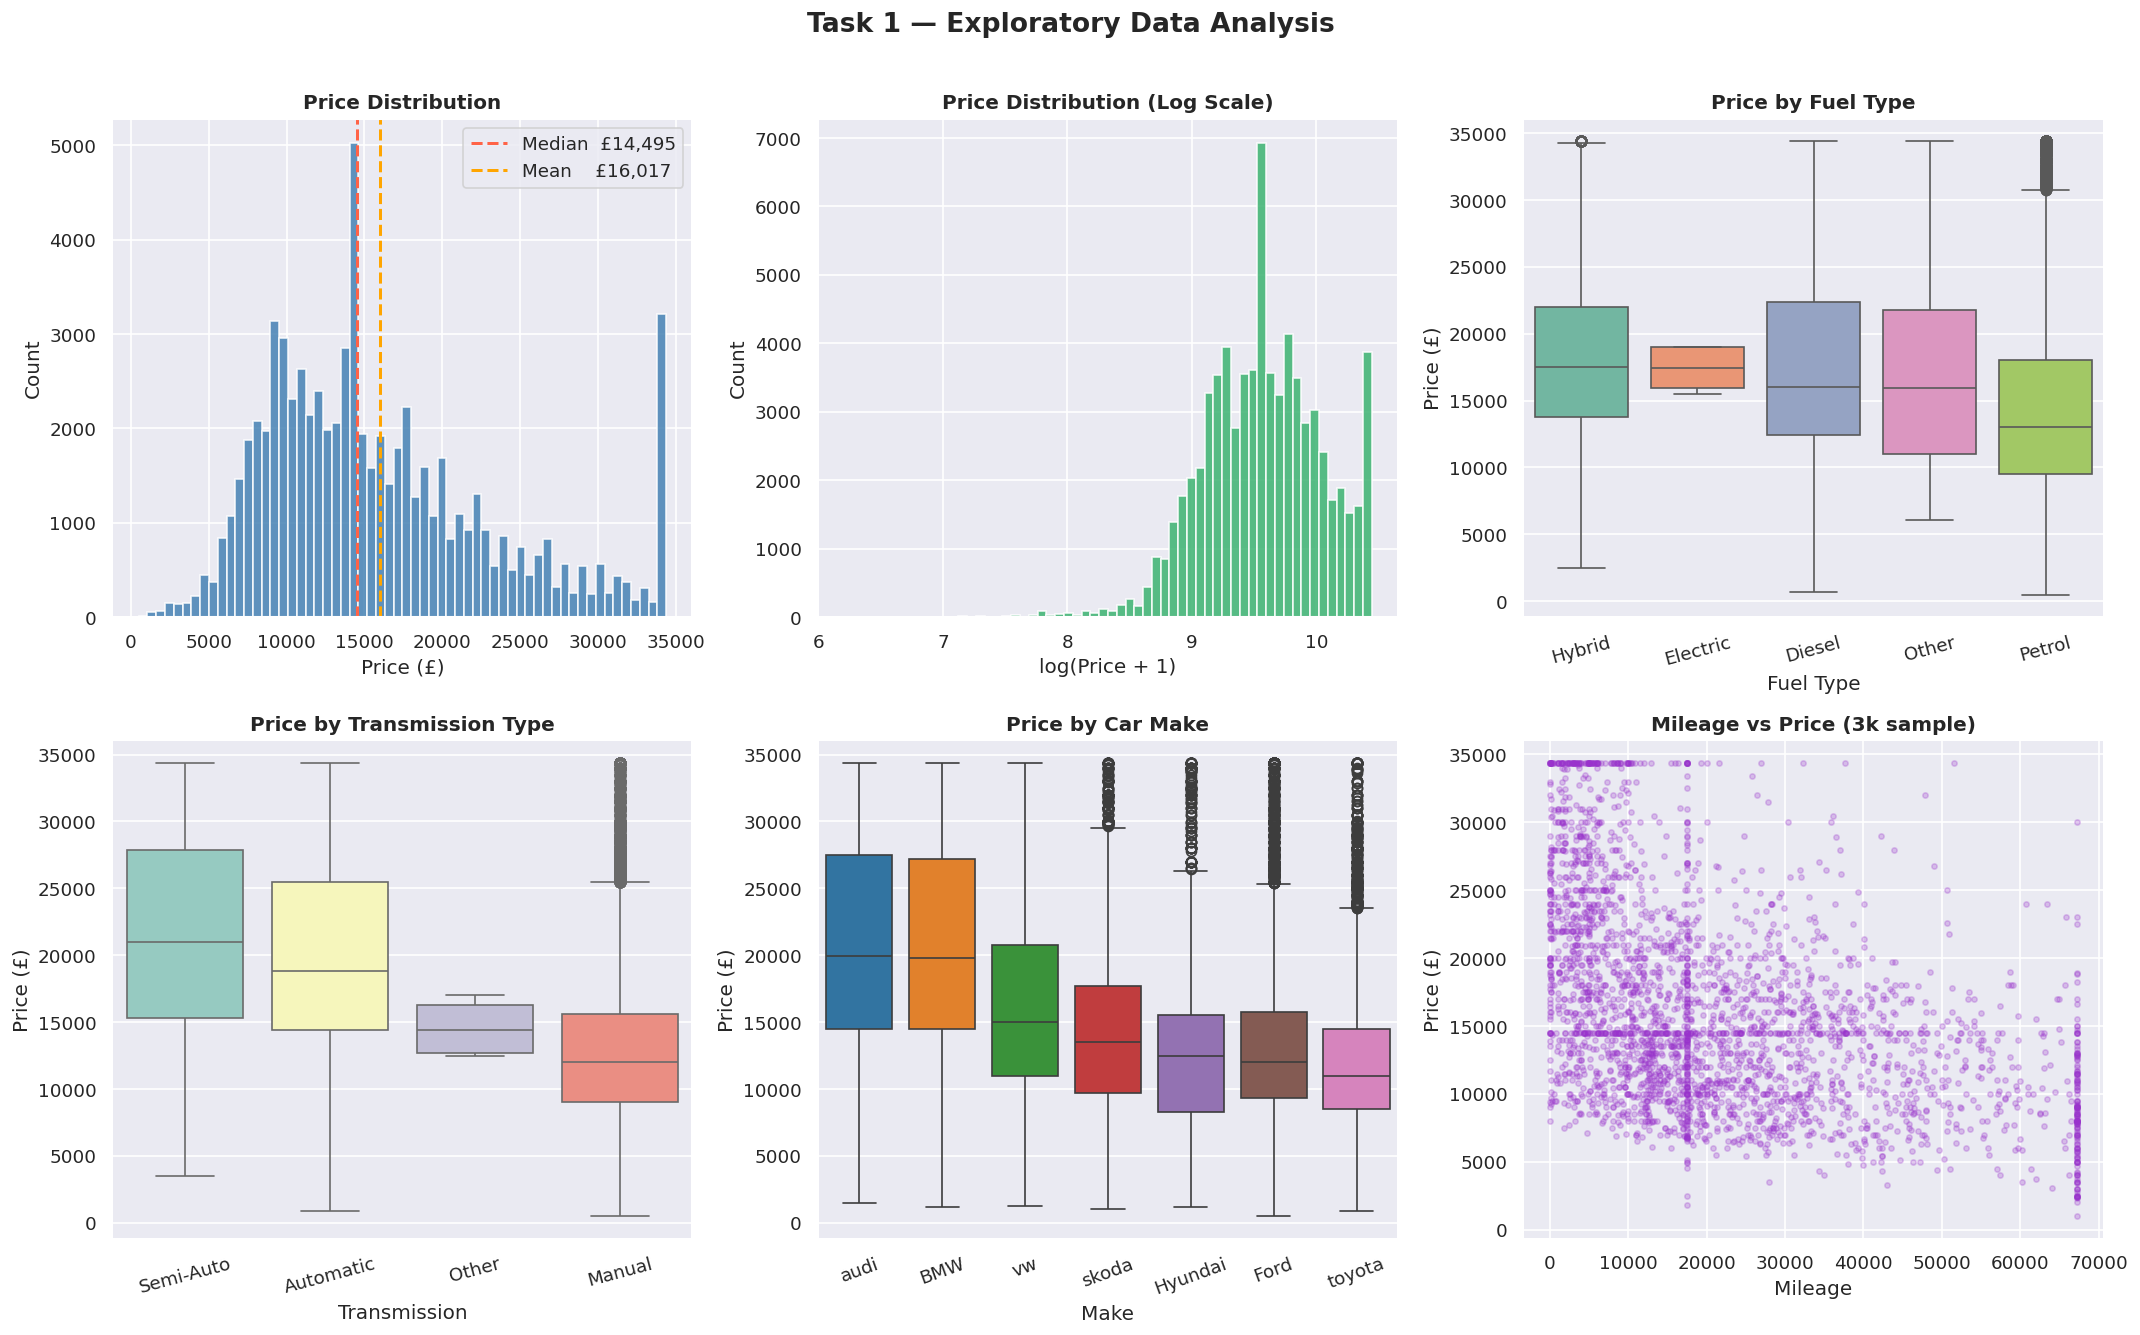

In [130]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Task 1 — Exploratory Data Analysis", fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Price Distribution Histogram ─────────────────────
ax = axes[0, 0]
ax.hist(df['price'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['price'].median(), color='tomato',  linestyle='--', linewidth=1.8, label=f"Median  £{df['price'].median():,.0f}")
ax.axvline(df['price'].mean(),   color='orange',  linestyle='--', linewidth=1.8, label=f"Mean    £{df['price'].mean():,.0f}")
ax.set_title("Price Distribution", fontweight='bold')
ax.set_xlabel("Price (£)")
ax.set_ylabel("Count")
ax.legend()

# ── Plot 2: Log-Scale Price (handles skew better) ────────────
ax = axes[0, 1]
ax.hist(np.log1p(df['price'].dropna()), bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_title("Price Distribution (Log Scale)", fontweight='bold')
ax.set_xlabel("log(Price + 1)")
ax.set_ylabel("Count")

# ── Plot 3: Price by Fuel Type ────────────────────────────────
ax = axes[0, 2]
order = df.groupby('fuelType')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='fuelType', y='price', order=order, palette='Set2', ax=ax)
ax.set_title("Price by Fuel Type", fontweight='bold')
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Price (£)")
ax.tick_params(axis='x', rotation=15)

# ── Plot 4: Price by Transmission ────────────────────────────
ax = axes[1, 0]
order2 = df.groupby('transmission')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='transmission', y='price', order=order2, palette='Set3', ax=ax)
ax.set_title("Price by Transmission Type", fontweight='bold')
ax.set_xlabel("Transmission")
ax.set_ylabel("Price (£)")
ax.tick_params(axis='x', rotation=15)

# ── Plot 5: Price by Car Make ─────────────────────────────────
ax = axes[1, 1]
order3 = df.groupby('Make')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Make', y='price', order=order3, palette='tab10', ax=ax)
ax.set_title("Price by Car Make", fontweight='bold')
ax.set_xlabel("Make")
ax.set_ylabel("Price (£)")
ax.tick_params(axis='x', rotation=20)

# ── Plot 6: Mileage vs Price (scatter) ───────────────────────
ax = axes[1, 2]
sample = df[['mileage','price']].dropna().sample(3000, random_state=42)
ax.scatter(sample['mileage'], sample['price'], alpha=0.25, s=10, color='darkorchid')
ax.set_title("Mileage vs Price (3k sample)", fontweight='bold')
ax.set_xlabel("Mileage")
ax.set_ylabel("Price (£)")

plt.tight_layout()
plt.show()



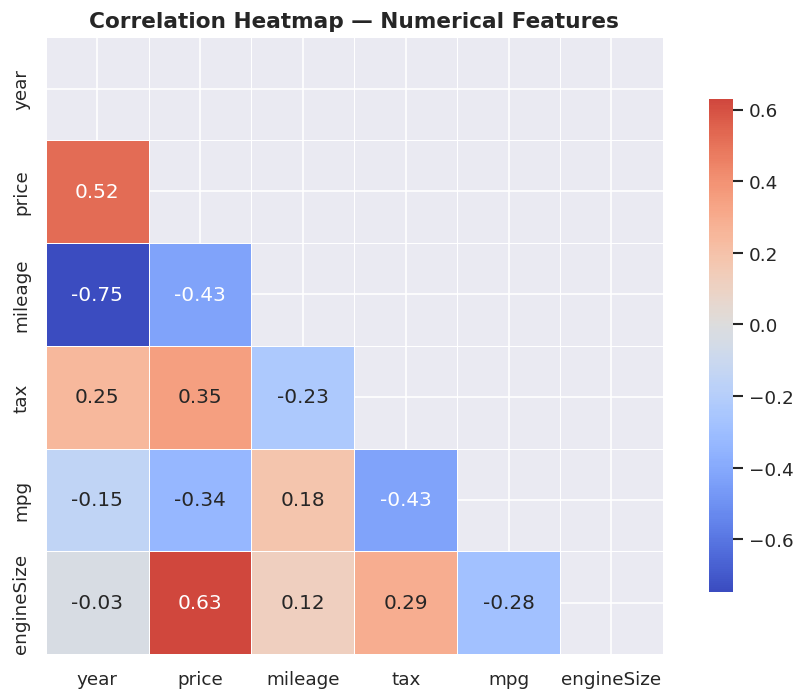

In [85]:
# 3.  CORRELATION HEATMAP
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8, 6))
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle mask
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap='coolwarm', center=0, linewidths=0.5,
    square=True, ax=ax2, cbar_kws={"shrink": 0.8}
)
ax2.set_title("Correlation Heatmap — Numerical Features", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("task1_correlation_heatmap.png", bbox_inches='tight')
plt.show()

In [86]:
# 4.  KEY FINDINGS SUMMARY
# ============================================================
print("\n" + "=" * 55)
print("  KEY EDA FINDINGS")
print("=" * 55)
print(f"""
1. Dataset Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns


2. Feature Types
   Numerical   : {numerical_cols}
   Categorical : {categorical_cols}

3. Missing Values
   ~{df.isnull().any(axis=1).sum():,} rows have at least one null value.
   Will be handled in Task 2.

4. Price Distribution
   Min  : £{df['price'].min():,.0f}
   Max  : £{df['price'].max():,.0f}
   Mean : £{df['price'].mean():,.0f}
   Std  : £{df['price'].std():,.0f}
   → Right-skewed: majority of cars are cheap, few are very expensive.
   → Log transformation recommended for regression.

5. Top Features Correlated with Price
{corr.round(4).to_string()}
   → Year and engineSize are positively correlated.
   → Mileage is negatively correlated (more miles = less value).
""")


  KEY EDA FINDINGS

1. Dataset Shape   : 72,435 rows × 10 columns


2. Feature Types
   Numerical   : ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
   Categorical : ['model', 'transmission', 'fuelType', 'Make']

3. Missing Values
   ~29,110 rows have at least one null value.
   Will be handled in Task 2.

4. Price Distribution
   Min  : £495
   Max  : £145,000
   Mean : £16,584
   Std  : £9,304
   → Right-skewed: majority of cars are cheap, few are very expensive.
   → Log transformation recommended for regression.

5. Top Features Correlated with Price
engineSize    0.6298
year          0.5194
mileage      -0.4275
tax           0.3532
mpg          -0.3356
   → Year and engineSize are positively correlated.
   → Mileage is negatively correlated (more miles = less value).



**preprocessing**

In [87]:
print(f"Original shape : {df.shape}")
print(f"Total nulls    : {df.isnull().sum().sum():,}")

Original shape : (72435, 10)
Total nulls    : 36,216


# STEP 1: HANDLE MISSING VALUES
# ============================================================
# Strategy:
##   Numerical columns   -> fill with MEDIAN
####     Reason: price, mileage are right-skewed. Median is more
###     robust than mean and won't be pulled by extreme values.
#
##   Categorical columns -> fill with MODE
####     Reason: most frequent category is the safest assumption
###     when we don't know the real value

In [88]:
# filling missing values

numerical_cols   = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
categorical_cols = ['model', 'transmission', 'fuelType', 'Make']

for col in numerical_cols:
    median_val = df[col].median()
    nulls = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"  {col:<12} -> filled {nulls:>4} nulls with median = {median_val:.2f}")

for col in categorical_cols:
    mode_val = df[col].mode()[0]
    nulls = df[col].isnull().sum()
    df[col] = df[col].fillna(mode_val)
    print(f"  {col:<12} -> filled {nulls:>4} nulls with mode  = '{mode_val}'")

print(f"\n  Remaining nulls: {df.isnull().sum().sum()}")

  year         -> filled 3622 nulls with median = 2017.00
  price        -> filled 3621 nulls with median = 14495.00
  mileage      -> filled 3622 nulls with median = 17521.00
  tax          -> filled 3621 nulls with median = 145.00
  mpg          -> filled 3621 nulls with median = 55.40
  engineSize   -> filled 3622 nulls with median = 1.60
  model        -> filled 3621 nulls with mode  = ' Fiesta'
  transmission -> filled 3623 nulls with mode  = 'Manual'
  fuelType     -> filled 3622 nulls with mode  = 'Petrol'
  Make         -> filled 3621 nulls with mode  = 'Ford'

  Remaining nulls: 0


In [89]:
# remove duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after  = len(df)
print(f"  Duplicates removed : {before - after:,} rows ({(before-after)/before*100:.2f}%)")
print(f"  Shape after dedup  : {df.shape}")

  Duplicates removed : 476 rows (0.66%)
  Shape after dedup  : (71959, 10)



#  **STEP 2: DETECT & HANDLE OUTLIERS** (IQR Capping / Winsorizing)
# ============================================
## Applied to: price, mileage, engineSize
#
## IQR formula:
###   lower fence = Q1 - 1.5 * IQR
###   upper fence = Q3 + 1.5 * IQR
#
### Values outside this range are CAPPED (not dropped).
### This keeps all rows while removing the distorting effect
### of extreme values on model training

In [90]:
# STEP 2: OUTLIER CAPPING (IQR Winsorizing)
outlier_cols = ['price', 'mileage', 'engineSize']

for col in outlier_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col]  = df[col].clip(lower=lower, upper=upper)
    print(f"  {col:<12} | fence [{lower:>8.1f}, {upper:>8.1f}] | capped {outliers:>5} values")

print(f"\n  Shape after capping: {df.shape}  <- no rows dropped")

  price        | fence [ -3985.0,  34375.0] | capped  2952 values
  mileage      | fence [-27855.2,  67270.8] | capped  3184 values
  engineSize   | fence [    -0.0,      3.2] | capped   327 values

  Shape after capping: (71959, 10)  <- no rows dropped


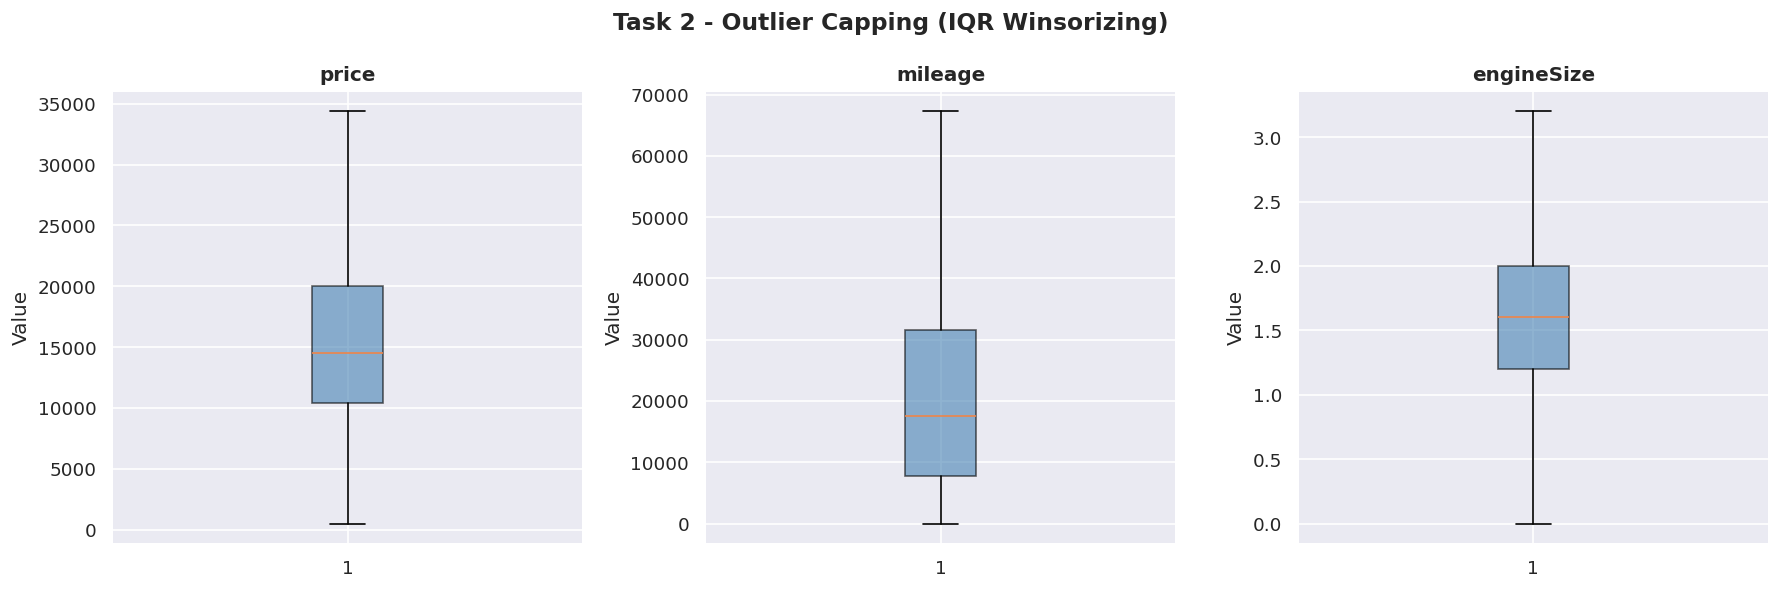

In [91]:
# Boxplots after capping
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Task 2 - Outlier Capping (IQR Winsorizing)", fontsize=14, fontweight='bold')
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel("Value")
plt.tight_layout()
plt.savefig("task2_outliers.png", bbox_inches='tight')
plt.show()


**STEP 3: TRAIN / TEST SPLIT**  

### We split BEFORE target encoding to prevent data leakage.
### Data leakage = test set prices accidentally influence the


In [92]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n" + "=" * 55)
print("STEP 3: TRAIN / TEST SPLIT (80/20)")
print("=" * 55)
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")


STEP 3: TRAIN / TEST SPLIT (80/20)
  X_train : (57567, 9)
  X_test  : (14392, 9)


**target encoding**

In [93]:
( """
Target Encoding = replace each category with the MEAN price
of that category, computed ONLY from the training set.

# Why Target Encoding?
- 'model' has 145 unique values -> OHE would add 145 columns
- Label Encoding assigns arbitrary integers with no meaning,
which misleads distance-based models like KNN
- Target Encoding captures real price signal per category:
e.g. BMW encodes higher than Ford because BMWs cost more
- Works well for both regression and KNN
#
# Leakage prevention:
- Mapping computed from y_train ONLY
- Unseen categories in test -> fallback to global_mean
""")

"\nTarget Encoding = replace each category with the MEAN price\nof that category, computed ONLY from the training set.\n\n# Why Target Encoding?\n- 'model' has 145 unique values -> OHE would add 145 columns\n- Label Encoding assigns arbitrary integers with no meaning,\nwhich misleads distance-based models like KNN\n- Target Encoding captures real price signal per category:\ne.g. BMW encodes higher than Ford because BMWs cost more\n- Works well for both regression and KNN\n#\n# Leakage prevention:\n- Mapping computed from y_train ONLY\n- Unseen categories in test -> fallback to global_mean\n"

In [94]:
# target encoding

global_mean = y_train.mean()

train_temp = X_train.copy()
train_temp['price'] = y_train.values

target_encoders = {}

for col in categorical_cols:
    mapping = train_temp.groupby(col)['price'].mean()
    target_encoders[col] = mapping

    X_train[col] = X_train[col].map(mapping).fillna(global_mean)
    X_test[col]  = X_test[col].map(mapping).fillna(global_mean)

    print(f"  {col:<12} -> encoded  ({mapping.shape[0]} unique categories)")

print("\n  Sample: Mean price per Make (from train set):")
print(target_encoders['Make'].sort_values(ascending=False).round(2).to_string())

  model        -> encoded  (144 unique categories)
  transmission -> encoded  (4 unique categories)
  fuelType     -> encoded  (5 unique categories)
  Make         -> encoded  (7 unique categories)

  Sample: Mean price per Make (from train set):
Make
audi       21149.90
BMW        20945.61
vw         16512.27
skoda      14281.99
Ford       12986.28
Hyundai    12868.35
toyota     12524.47


**Feature scalling**(standardScalar)

In [95]:
# why standard scalar ?
"""
- Transforms each feature to mean=0, std=1
- KNN is purely distance-based: without scaling, mileage
(range 0-150k) would dominate engineSize (range 1-5)
- Linear Regression also benefits: coefficients become
comparable and gradient descent converges faster

"""

'\n- Transforms each feature to mean=0, std=1\n- KNN is purely distance-based: without scaling, mileage\n(range 0-150k) would dominate engineSize (range 1-5)\n- Linear Regression also benefits: coefficients become\ncomparable and gradient descent converges faster\n\n'

In [96]:
# Feature scalling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("  Scaler fit on training set only")
print("\n  Feature means after scaling (should be ~0.0):")
print(X_train_scaled.mean().round(4).to_string())
print("\n  Feature stds after scaling (should be ~1.0):")
print(X_train_scaled.std().round(4).to_string())

  Scaler fit on training set only

  Feature means after scaling (should be ~0.0):
model           0.0
year           -0.0
transmission   -0.0
mileage        -0.0
fuelType        0.0
tax             0.0
mpg             0.0
engineSize     -0.0
Make           -0.0

  Feature stds after scaling (should be ~1.0):
model           1.0
year            1.0
transmission    1.0
mileage         1.0
fuelType        1.0
tax             1.0
mpg             1.0
engineSize      1.0
Make            1.0


In [97]:
# STEP 6: SAVE OUTPUTS
# ============================================================
X_train_scaled.to_csv("X_train_scaled.csv", index=False)
X_test_scaled.to_csv("X_test_scaled.csv",   index=False)
y_train.to_csv("y_train.csv",               index=False)
y_test.to_csv("y_test.csv",                 index=False)

**final summary**

In [98]:
print("\n" + "=" * 55)
print("PREPROCESSING COMPLETE")
print("=" * 55)
print(f"""
  Original shape       : {df.shape[0]:,} rows x {df.shape[1]} columns
  Rows dropped         : 0  (all rows preserved)
  Nulls remaining      : 0

  [Step 1] Null handling
    Numerical   -> median fill
    Categorical -> mode fill

  [Step 2] Outlier handling
    IQR capping on price, mileage, engineSize
    No rows dropped - values clipped to IQR fences

  [Step 3] Split
    80% train / 20% test (random_state=42)

  [Step 4] Encoding
    Target Encoding on all 4 categorical columns
    Fit on train only -> no data leakage

  [Step 5] Scaling
    StandardScaler fit on train, applied to both sets

  Final shapes:
    X_train_scaled : {X_train_scaled.shape}
    X_test_scaled  : {X_test_scaled.shape}
    y_train        : {y_train.shape}
    y_test         : {y_test.shape}

  Saved files:
    X_train_scaled.csv, X_test_scaled.csv
    y_train.csv, y_test.csv
""")


PREPROCESSING COMPLETE

  Original shape       : 71,959 rows x 10 columns
  Rows dropped         : 0  (all rows preserved)
  Nulls remaining      : 0

  [Step 1] Null handling
    Numerical   -> median fill
    Categorical -> mode fill

  [Step 2] Outlier handling
    IQR capping on price, mileage, engineSize
    No rows dropped - values clipped to IQR fences

  [Step 3] Split
    80% train / 20% test (random_state=42)

  [Step 4] Encoding
    Target Encoding on all 4 categorical columns
    Fit on train only -> no data leakage

  [Step 5] Scaling
    StandardScaler fit on train, applied to both sets

  Final shapes:
    X_train_scaled : (57567, 9)
    X_test_scaled  : (14392, 9)
    y_train        : (57567,)
    y_test         : (14392,)

  Saved files:
    X_train_scaled.csv, X_test_scaled.csv
    y_train.csv, y_test.csv



In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression:
MAE: 2347.316055102016
RMSE: 3246.4159628631332
R2: 0.8100504276533272


**Regression target**

In [100]:
print(f"  Target (price) stats:")
print(df['price'].describe().round(2).to_string())

  Target (price) stats:
count    71959.00
mean     16017.44
std       7455.88
min        495.00
25%      10400.00
50%      14495.00
75%      19990.00
max      34375.00


In [101]:
"""
 Strategy: Use 33rd and 67th percentiles as thresholds.
#
# Justification:
#   - Splitting at percentiles instead of arbitrary values
#     (e.g. £10k / £20k) ensures BALANCED classes.
#   - Balanced classes prevent KNN from being biased toward
#     the majority class.
#   - Using the data distribution to define boundaries is
#     the statistically correct approach.
#
# Thresholds (from data):
#   Cheap     : price <= 11,690  (bottom 33%)
#   Moderate  : 11,690 < price <= 17,800  (middle 34%)
#   Expensive : price > 17,800   (top 33%)
"""


'\n Strategy: Use 33rd and 67th percentiles as thresholds.\n#\n# Justification:\n#   - Splitting at percentiles instead of arbitrary values\n#     (e.g. £10k / £20k) ensures BALANCED classes.\n#   - Balanced classes prevent KNN from being biased toward\n#     the majority class.\n#   - Using the data distribution to define boundaries is\n#     the statistically correct approach.\n#\n# Thresholds (from data):\n#   Cheap     : price <= 11,690  (bottom 33%)\n#   Moderate  : 11,690 < price <= 17,800  (middle 34%)\n#   Expensive : price > 17,800   (top 33%)\n'

In [102]:

low_thresh  = df['price'].quantile(0.33)
high_thresh = df['price'].quantile(0.67)

print(f"  Lower threshold (33rd pct) : £{low_thresh:,.0f}")
print(f"  Upper threshold (67th pct) : £{high_thresh:,.0f}")

def price_category(price):
    if price <= low_thresh:
        return 'Cheap'
    elif price <= high_thresh:
        return 'Moderate'
    else:
        return 'Expensive'

df['price_category'] = df['price'].apply(price_category)

print("\n  Class distribution:")
counts = df['price_category'].value_counts()
for cat, count in counts.items():
    print(f"    {cat:<12}: {count:>6,}  ({count/len(df)*100:.1f}%)")

  Lower threshold (33rd pct) : £11,690
  Upper threshold (67th pct) : £17,800

  Class distribution:
    Moderate    : 24,483  (34.0%)
    Cheap       : 23,749  (33.0%)
    Expensive   : 23,727  (33.0%)


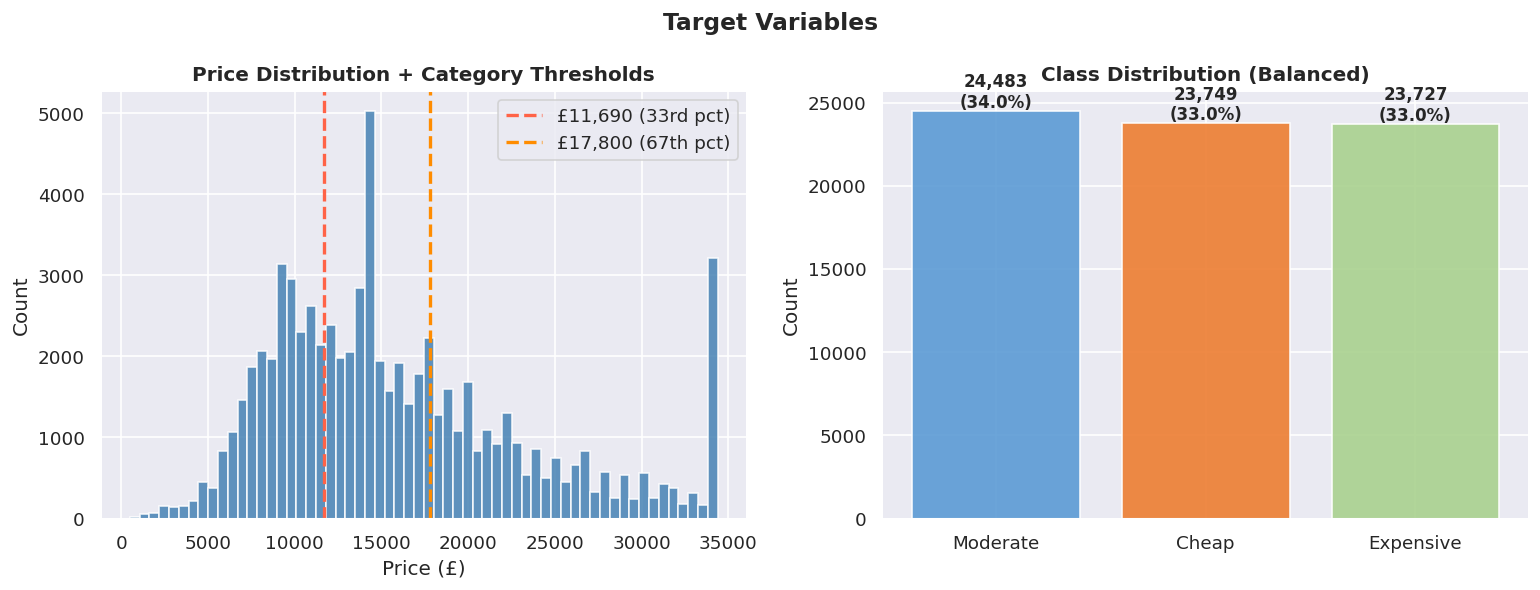

In [103]:
#visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Target Variables", fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(df['price'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(low_thresh,  color='tomato',       linestyle='--', lw=2, label=f'£{low_thresh:,.0f} (33rd pct)')
ax.axvline(high_thresh, color='darkorange',   linestyle='--', lw=2, label=f'£{high_thresh:,.0f} (67th pct)')
ax.set_title("Price Distribution + Category Thresholds", fontweight='bold')
ax.set_xlabel("Price (£)")
ax.set_ylabel("Count")
ax.legend()

ax = axes[1]
colors = ['#5B9BD5', '#ED7D31', '#A9D18E']
ax.bar(counts.index, counts.values, color=colors, edgecolor='white', alpha=0.9)
for i, (cat, val) in enumerate(counts.items()):
    ax.text(i, val + 200, f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')
ax.set_title("Class Distribution (Balanced)", fontweight='bold')
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("task3_targets.png", bbox_inches='tight')
plt.show()

**prepare features for both models**

In [104]:
X = df.drop(columns=['price', 'price_category'])
y_reg = df['price']
y_clf = df['price_category']

# Split (same split for both models — ensures fair comparison)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

# Target Encoding (fit on train only — no leakage)
global_mean = y_train_reg.mean()
train_temp  = X_train.copy()
train_temp['price'] = y_train_reg.values

for col in categorical_cols:
    mapping = train_temp.groupby(col)['price'].mean()
    X_train[col] = X_train[col].map(mapping).fillna(global_mean)
    X_test[col]  = X_test[col].map(mapping).fillna(global_mean)

# StandardScaler (fit on train only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print(f"\n  X_train: {X_train_scaled.shape}  |  X_test: {X_test_scaled.shape}")


  X_train: (57567, 9)  |  X_test: (14392, 9)


In [105]:
print("\n" + "=" * 55)
print("TASK 4: LINEAR REGRESSION")
print("=" * 55)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)
y_pred_reg = lr.predict(X_test_scaled)

# Evaluation metrics
mae  = mean_absolute_error(y_test_reg, y_pred_reg)
mse  = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_reg, y_pred_reg)
mape = np.mean(np.abs((y_test_reg - y_pred_reg) / y_test_reg)) * 100

print(f"""
  MAE   (Mean Absolute Error)       : £{mae:,.2f}
        → On average, predictions are off by £{mae:,.0f}

  MSE   (Mean Squared Error)        : {mse:,.2f}
        → Heavily penalises large errors (squared)

  RMSE  (Root Mean Squared Error)   : £{rmse:,.2f}
        → Same unit as price; error scale in £

  R²    (Coefficient of Determination) : {r2:.4f}
        → Model explains {r2*100:.1f}% of price variance

  MAPE  (Mean Absolute % Error)     : {mape:.2f}%
        → Predictions are off by {mape:.1f}% on average
""")


TASK 4: LINEAR REGRESSION

  MAE   (Mean Absolute Error)       : £2,347.32
        → On average, predictions are off by £2,347

  MSE   (Mean Squared Error)        : 10,539,216.60
        → Heavily penalises large errors (squared)

  RMSE  (Root Mean Squared Error)   : £3,246.42
        → Same unit as price; error scale in £

  R²    (Coefficient of Determination) : 0.8101
        → Model explains 81.0% of price variance

  MAPE  (Mean Absolute % Error)     : 17.39%
        → Predictions are off by 17.4% on average



In [106]:
# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature'    : X_train_scaled.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("  Feature Coefficients (after scaling — comparable):")
print(coef_df.to_string(index=False))

  Feature Coefficients (after scaling — comparable):
     Feature  Coefficient
       model  2814.578664
        year  2179.465007
  engineSize  1839.472357
     mileage -1816.428479
transmission  1062.415090
        Make   516.480024
         mpg  -325.603088
         tax    52.798474
    fuelType     4.992774


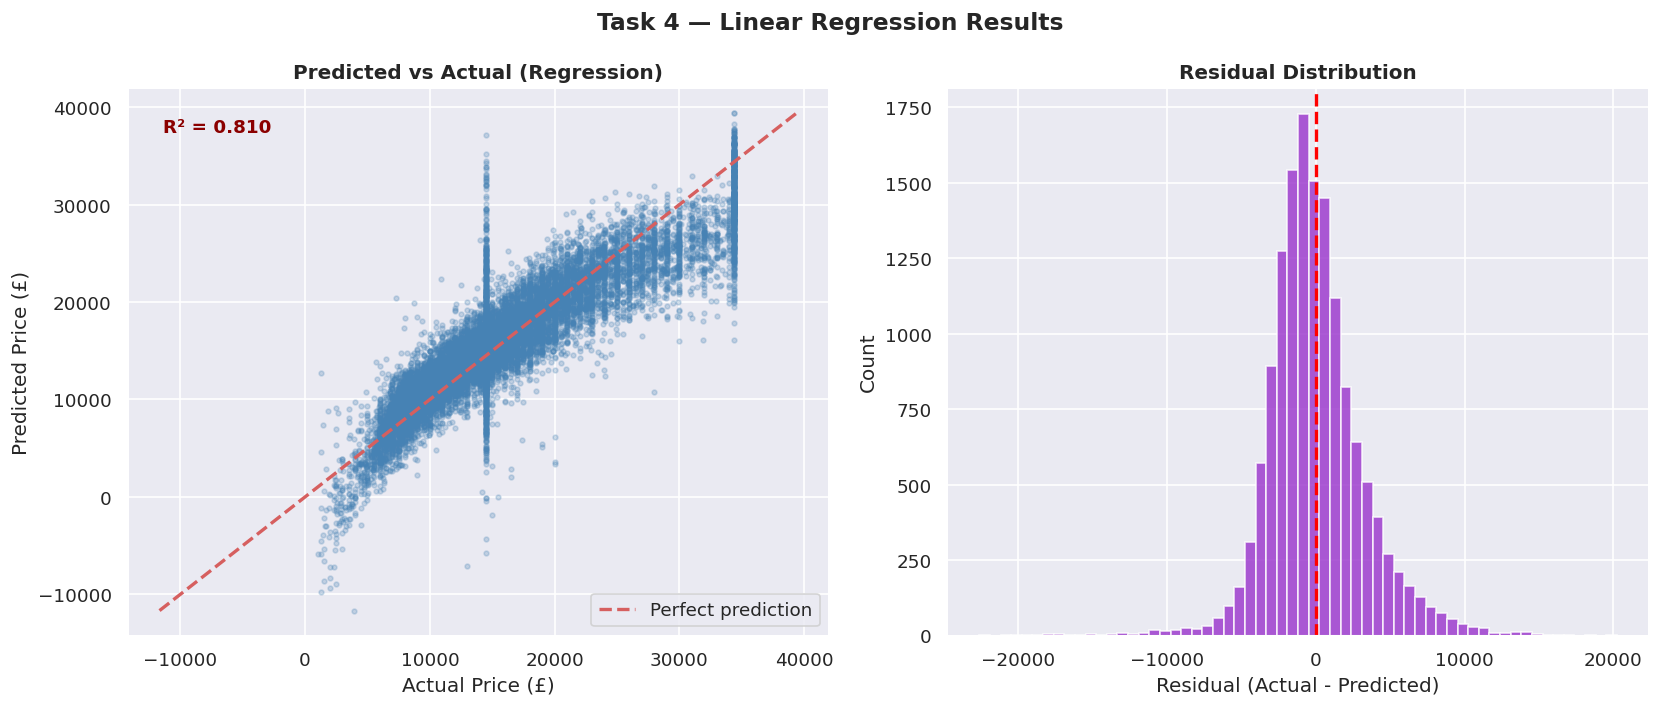

In [107]:
# ── Task 7: Predicted vs Actual plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Task 4 — Linear Regression Results", fontsize=14, fontweight='bold')

ax = axes[0]
ax.scatter(y_test_reg, y_pred_reg, alpha=0.25, s=8, color='steelblue')
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel("Actual Price (£)")
ax.set_ylabel("Predicted Price (£)")
ax.set_title("Predicted vs Actual (Regression)", fontweight='bold')
ax.legend()
ax.text(0.05, 0.92, f'R² = {r2:.3f}', transform=ax.transAxes,
        fontsize=11, color='darkred', fontweight='bold')

ax = axes[1]
residuals = y_test_reg - y_pred_reg
ax.hist(residuals, bins=60, color='darkorchid', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution", fontweight='bold')

plt.tight_layout()
plt.savefig("task4_regression.png", bbox_inches='tight')
plt.show()

**KNN classification**

In [110]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

print("TASK 5: KNN CLASSIFICATION (Grid Search + K-Fold)")
print("=" * 55)

# Grid Search with K-Fold Cross Validation
# Parameters to search:
#   - n_neighbors : [3, 5, 7, 9, 11, 13]
#   - metric      : euclidean, manhattan

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'metric'     : ['euclidean', 'manhattan']
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

print("  Running Grid Search with 5-Fold CV...")
grid_search.fit(X_train_scaled, y_train_clf)

best_k      = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']
best_cv_acc = grid_search.best_score_

print(f"\n  Best parameters  : k={best_k}, metric='{best_metric}'")
print(f"  Best CV accuracy : {best_cv_acc*100:.2f}%")

TASK 5: KNN CLASSIFICATION (Grid Search + K-Fold)
  Running Grid Search with 5-Fold CV...

  Best parameters  : k=9, metric='manhattan'
  Best CV accuracy : 85.01%


In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Train best model and evaluate on test set
best_knn = grid_search.best_estimator_
y_pred_clf = best_knn.predict(X_test_scaled)

acc  = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf, average='weighted')
rec  = recall_score(y_test_clf, y_pred_clf, average='weighted')
f1   = f1_score(y_test_clf, y_pred_clf, average='weighted')

print(f"""
  Test Set Evaluation (best model):
    Accuracy  : {acc*100:.2f}%
    Precision : {prec*100:.2f}%
    Recall    : {rec*100:.2f}%
    F1-Score  : {f1*100:.2f}%
""")

print("  Full Classification Report:")
print(classification_report(y_test_clf, y_pred_clf,
      target_names=['Cheap', 'Expensive', 'Moderate']))


  Test Set Evaluation (best model):
    Accuracy  : 85.59%
    Precision : 85.45%
    Recall    : 85.59%
    F1-Score  : 85.49%

  Full Classification Report:
              precision    recall  f1-score   support

       Cheap       0.88      0.90      0.89      4780
   Expensive       0.88      0.91      0.89      4799
    Moderate       0.80      0.76      0.78      4813

    accuracy                           0.86     14392
   macro avg       0.85      0.86      0.86     14392
weighted avg       0.85      0.86      0.85     14392



In [114]:
# Grid Search results summary
print("\n  All parameter combinations (CV accuracy):")
results = pd.DataFrame(grid_search.cv_results_)
results = results[['param_n_neighbors','param_metric','mean_test_score']].copy()
results.columns = ['k','metric','cv_accuracy']
results['cv_accuracy'] = (results['cv_accuracy'] * 100).round(2)
results = results.sort_values('cv_accuracy', ascending=False)
print(results.to_string(index=False))


  All parameter combinations (CV accuracy):
 k    metric  cv_accuracy
 9 manhattan        85.01
13 manhattan        84.99
11 manhattan        84.98
 7 manhattan        84.85
 5 manhattan        84.66
 9 euclidean        84.26
11 euclidean        84.20
 7 euclidean        84.17
13 euclidean        84.13
 5 euclidean        83.92
 3 manhattan        83.78
 3 euclidean        83.26


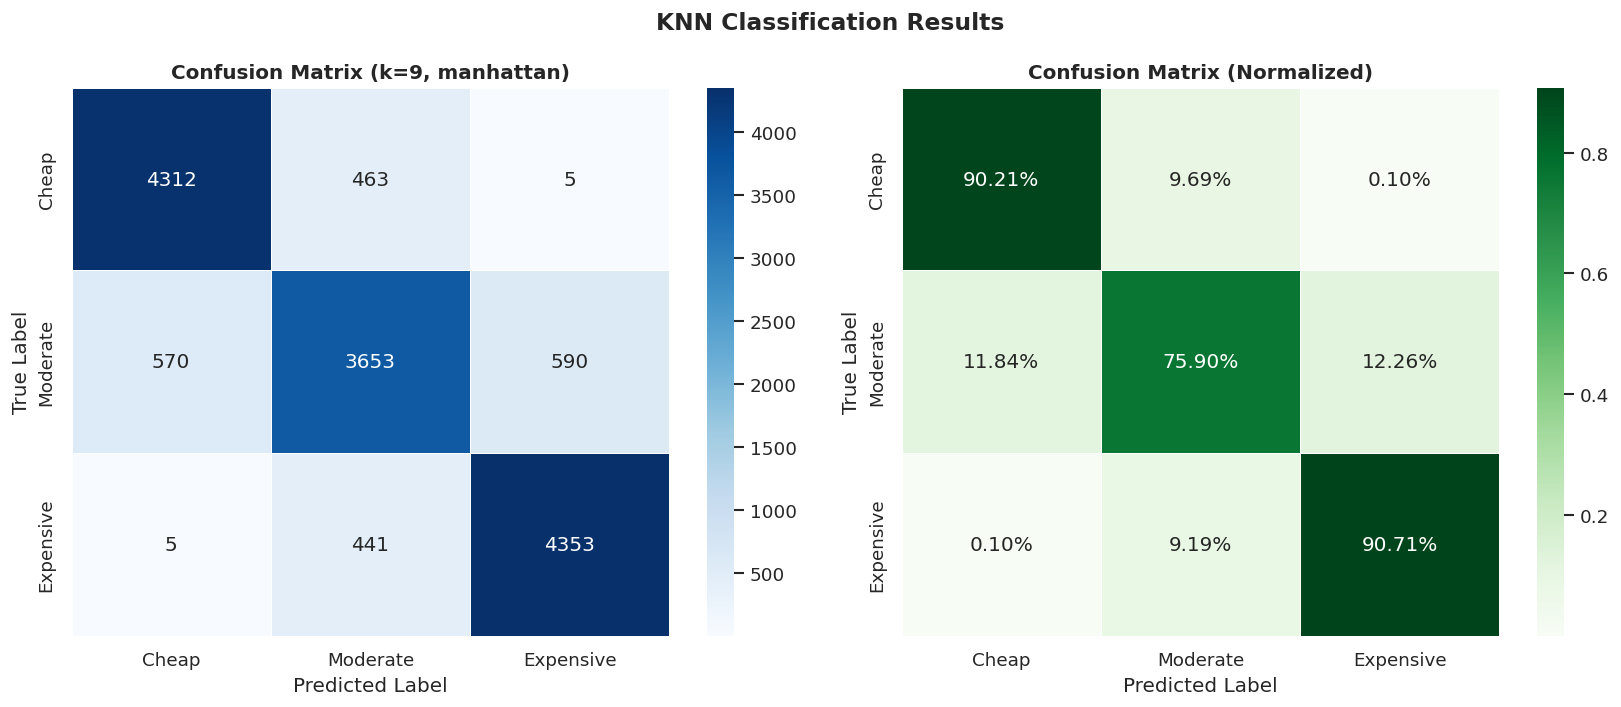

In [133]:
from sklearn.metrics import confusion_matrix

# ── Confusion Matrix ─────────────────────────────────────────
cm     = confusion_matrix(y_test_clf, y_pred_clf,
                          labels=['Cheap', 'Moderate', 'Expensive'])
labels = ['Cheap', 'Moderate', 'Expensive']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("KNN Classification Results", fontsize=14, fontweight='bold')

ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, cbar=True)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Confusion Matrix (k={best_k}, {best_metric})", fontweight='bold')
# Normalize confusion matrix (shows % per true class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ax = axes[1]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, cbar=True)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix (Normalized)", fontweight='bold')

plt.tight_layout()
plt.savefig("task5_knn.png", bbox_inches='tight')
plt.show()

In [119]:
# Confusion matrix explanation
print("""
  Confusion Matrix Explanation:
  - Rows = True labels (what the car actually is)
  - Cols = Predicted labels (what the model said)
  - Diagonal = correct predictions (higher is better)
  - Off-diagonal = mistakes:
      e.g. True=Cheap but Predicted=Moderate means the model
      thought a cheap car was moderate-priced
  - The normalized matrix shows the % per true class,
    making it easier to compare across unequal class sizes
""")


  Confusion Matrix Explanation:
  - Rows = True labels (what the car actually is)
  - Cols = Predicted labels (what the model said)
  - Diagonal = correct predictions (higher is better)
  - Off-diagonal = mistakes:
      e.g. True=Cheap but Predicted=Moderate means the model
      thought a cheap car was moderate-priced
  - The normalized matrix shows the % per true class,
    making it easier to compare across unequal class sizes



**Analysis and discussion**

In [120]:
print("\n" + "=" * 55)
print("TASK 6: ANALYSIS AND DISCUSSION")
print("=" * 55)

print(f"""
  6.1 MODEL COMPARISON
  ─────────────────────────────────────────────────────────

  Linear Regression results:
    R²   = {r2:.4f}  (explains {r2*100:.1f}% of price variance)
    RMSE = £{rmse:,.0f}
    MAPE = {mape:.1f}%

  KNN Classification results:
    Accuracy  = {acc*100:.2f}%
    F1-Score  = {f1*100:.2f}%

  Which performed "better"?
    "Better" means different things for each model:
    - For regression  → we want R² close to 1 and low RMSE.
      R²={r2:.2f} means the model captures most price variance,
      but RMSE=£{rmse:,.0f} shows it still struggles with
      exact prices on outlier cars.
    - For classification → accuracy={acc*100:.1f}% means the model
      correctly assigns price category most of the time.

  Is classification easier than regression on this dataset?
    YES. Classification is easier because:
    - It only needs to get the "zone" right (Cheap/Moderate/
      Expensive), not the exact value.
    - Small prediction errors don't matter if the car stays
      in the same category.
    - Balanced classes (≈33% each) give KNN fair training data.

  Does converting price to categories lose information?
    YES — inevitably. A car worth £11,500 and one worth £11,700
    are both "Cheap" despite a £200 difference. More importantly,
    a car at £11,680 (just under threshold) and one at £11,700
    (just over) land in different classes despite being nearly
    identical. This is the boundary problem in classification.
""")


TASK 6: ANALYSIS AND DISCUSSION

  6.1 MODEL COMPARISON
  ─────────────────────────────────────────────────────────

  Linear Regression results:
    R²   = 0.8101  (explains 81.0% of price variance)
    RMSE = £3,246
    MAPE = 17.4%

  KNN Classification results:
    Accuracy  = 85.59%
    F1-Score  = 85.49%

  Which performed "better"?
    "Better" means different things for each model:
    - For regression  → we want R² close to 1 and low RMSE.
      R²=0.81 means the model captures most price variance,
      but RMSE=£3,246 shows it still struggles with
      exact prices on outlier cars.
    - For classification → accuracy=85.6% means the model
      correctly assigns price category most of the time.

  Is classification easier than regression on this dataset?
    YES. Classification is easier because:
    - It only needs to get the "zone" right (Cheap/Moderate/
      Expensive), not the exact value.
    - Small prediction errors don't matter if the car stays
      in the same c

In [121]:

print("  6.2 SENSITIVITY ANALYSIS")
print("  ─────────────────────────────────────────────────────")

# A) Remove most correlated feature (engineSize, r=0.63)
print("\n  A) Remove most correlated feature (engineSize, r=0.63)")
X_train_no_eng = X_train_scaled.drop(columns=['engineSize'])
X_test_no_eng  = X_test_scaled.drop(columns=['engineSize'])

lr_no_eng = LinearRegression()
lr_no_eng.fit(X_train_no_eng, y_train_reg)
r2_no_eng = r2_score(y_test_reg, lr_no_eng.predict(X_test_no_eng))
print(f"    R² with    engineSize : {r2:.4f}")
print(f"    R² without engineSize : {r2_no_eng:.4f}")
print(f"    R² drop               : {r2 - r2_no_eng:.4f}  → {'significant' if r2-r2_no_eng > 0.03 else 'moderate'} impact")

  6.2 SENSITIVITY ANALYSIS
  ─────────────────────────────────────────────────────

  A) Remove most correlated feature (engineSize, r=0.63)
    R² with    engineSize : 0.8101
    R² without engineSize : 0.7870
    R² drop               : 0.0230  → moderate impact


In [122]:
# B) KNN without scaling
print("\n  B) KNN without scaling (using raw encoded values)")
knn_no_scale = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_no_scale.fit(X_train, y_train_clf)
acc_no_scale = accuracy_score(y_test_clf, knn_no_scale.predict(X_test))
print(f"    Accuracy WITH    scaling : {acc*100:.2f}%")
print(f"    Accuracy WITHOUT scaling : {acc_no_scale*100:.2f}%")
print(f"    Accuracy drop            : {(acc - acc_no_scale)*100:.2f}%")
print(f"    → Scaling {'matters a lot' if abs(acc-acc_no_scale) > 0.05 else 'has some effect'} for KNN on this dataset")


  B) KNN without scaling (using raw encoded values)
    Accuracy WITH    scaling : 85.59%
    Accuracy WITHOUT scaling : 77.20%
    Accuracy drop            : 8.39%
    → Scaling matters a lot for KNN on this dataset


In [123]:
# C) Different price thresholds
print("\n  C) Different price thresholds")
alt_low  = 10000
alt_high = 20000

def price_cat_alt(price):
    if price <= alt_low:  return 'Cheap'
    elif price <= alt_high: return 'Moderate'
    else: return 'Expensive'

y_clf_alt   = df['price'].apply(price_cat_alt)
_, _, y_train_alt, y_test_alt = train_test_split(
    X, y_clf_alt, test_size=0.2, random_state=42
)
knn_alt = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_alt.fit(X_train_scaled, y_train_alt)
acc_alt = accuracy_score(y_test_alt, knn_alt.predict(X_test_scaled))

print(f"    Original thresholds (£{low_thresh:,.0f} / £{high_thresh:,.0f}) → Accuracy: {acc*100:.2f}%")
print(f"    Alt thresholds      (£{alt_low:,}   / £{alt_high:,})   → Accuracy: {acc_alt*100:.2f}%")
print(f"    → {'Accuracy changed significantly' if abs(acc-acc_alt) > 0.03 else 'Accuracy is relatively stable'} with different thresholds")


  C) Different price thresholds
    Original thresholds (£11,690 / £17,800) → Accuracy: 85.59%
    Alt thresholds      (£10,000   / £20,000)   → Accuracy: 86.60%
    → Accuracy is relatively stable with different thresholds


**Additional visualizaiton**

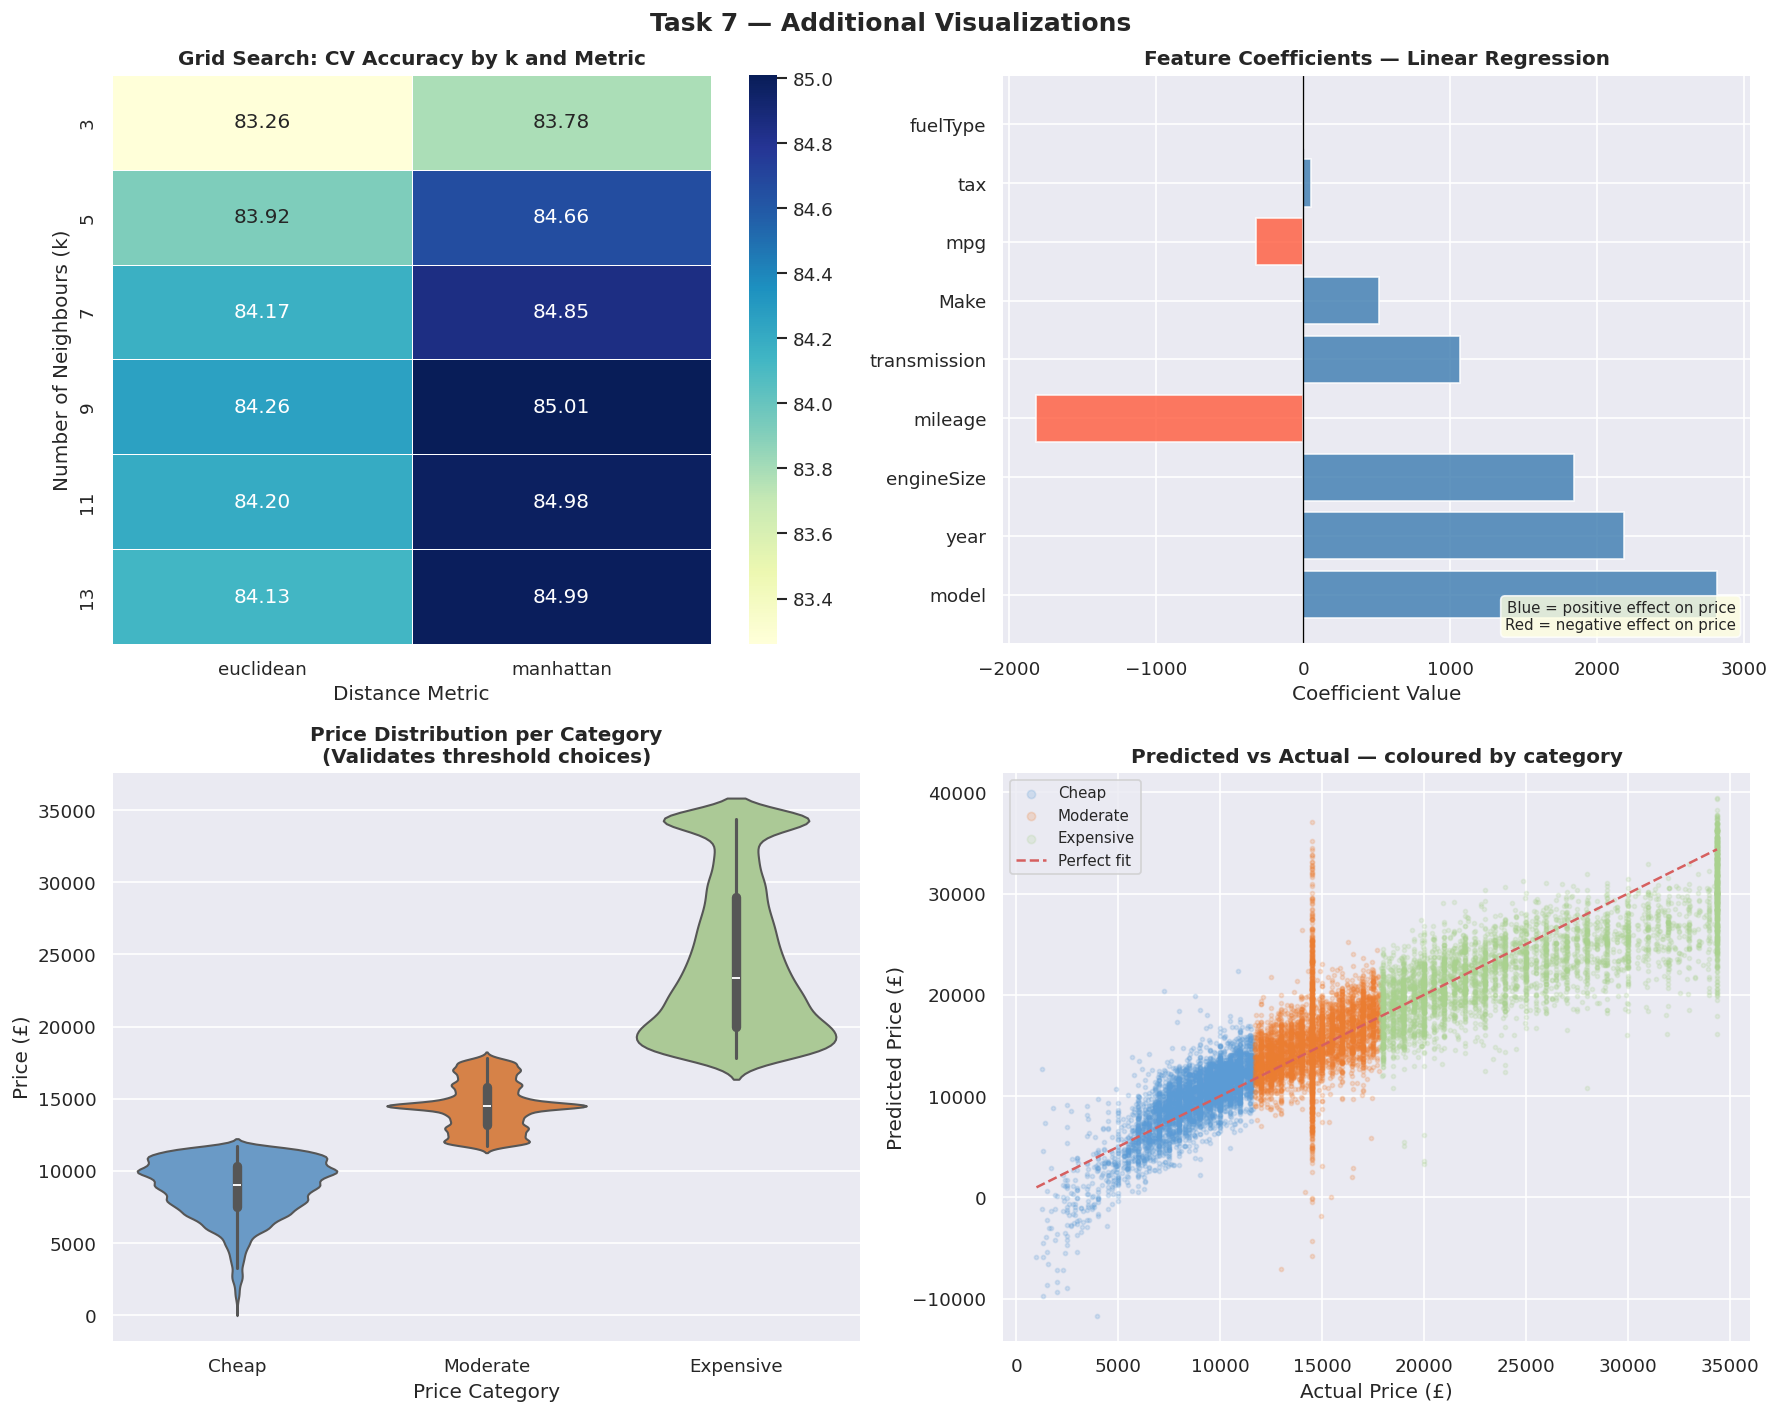

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Task 7 — Additional Visualizations", fontsize=15, fontweight='bold')

# ── Plot 1: Grid Search Heatmap (k vs metric) ────────────────
ax = axes[0, 0]
pivot = results.pivot(index='k', columns='metric', values='cv_accuracy')
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title("Grid Search: CV Accuracy by k and Metric", fontweight='bold')
ax.set_xlabel("Distance Metric")
ax.set_ylabel("Number of Neighbours (k)")
# ── Plot 2: Feature Coefficients (regression) ───────────────
ax = axes[0, 1]
colors_coef = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Feature Coefficients — Linear Regression", fontweight='bold')
ax.set_xlabel("Coefficient Value")
# Explanation note
ax.text(0.98, 0.02,
        "Blue = positive effect on price\nRed = negative effect on price",
        transform=ax.transAxes, fontsize=9,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
# ── Plot 3: Price distribution per category ──────────────────
ax = axes[1, 0]
order = ['Cheap', 'Moderate', 'Expensive']
palette = {'Cheap': '#5B9BD5', 'Moderate': '#ED7D31', 'Expensive': '#A9D18E'}
sns.violinplot(data=df, x='price_category', y='price', order=order,
               palette=palette, ax=ax, inner='box')
ax.set_title("Price Distribution per Category\n(Validates threshold choices)", fontweight='bold')
ax.set_xlabel("Price Category")
ax.set_ylabel("Price (£)")
# ── Plot 4: Actual vs Predicted by category ──────────────────
ax = axes[1, 1]
# Color each point by its TRUE price category
true_cats_test = y_test_clf.values
cat_colors = {'Cheap': '#5B9BD5', 'Moderate': '#ED7D31', 'Expensive': '#A9D18E'}
for cat in order:
    mask = true_cats_test == cat
    ax.scatter(
        y_test_reg.values[mask],
        y_pred_reg[mask],
        alpha=0.2, s=6,
        color=cat_colors[cat], label=cat
    )
min_v, max_v = y_test_reg.min(), y_test_reg.max()
ax.plot([min_v, max_v], [min_v, max_v], 'r--', lw=1.5, label='Perfect fit')
ax.set_title("Predicted vs Actual — coloured by category", fontweight='bold')
ax.set_xlabel("Actual Price (£)")
ax.set_ylabel("Predicted Price (£)")
ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig("task7_additional_plots.png", bbox_inches='tight')
plt.show()




In [134]:
#  FINAL SUMMARY
# ============================================================
print("\n" + "=" * 55)
print("ALL TASKS COMPLETE — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"""
  Target Variables:
    Regression  : continuous price (£495 – £34,375)
    Classification thresholds:
      Cheap     : price <= £{low_thresh:,.0f}
      Moderate  : £{low_thresh:,.0f} < price <= £{high_thresh:,.0f}
      Expensive : price > £{high_thresh:,.0f}

   Linear Regression:
    R²   = {r2:.4f}
    MAE  = £{mae:,.2f}
    RMSE = £{rmse:,.2f}
    MAPE = {mape:.2f}%

   KNN Classification:
    Best k      = {best_k}
    Best metric = {best_metric}
    CV Accuracy = {best_cv_acc*100:.2f}%
    Test Accuracy  = {acc*100:.2f}%
    Test F1-Score  = {f1*100:.2f}%

   Sensitivity Analysis:
    Without engineSize : R² drops from {r2:.4f} to {r2_no_eng:.4f}
    Without scaling    : KNN accuracy drops from {acc*100:.1f}% to {acc_no_scale*100:.1f}%
    Alt thresholds     : KNN accuracy = {acc_alt*100:.2f}%""")


ALL TASKS COMPLETE — FINAL RESULTS SUMMARY

  Target Variables:
    Regression  : continuous price (£495 – £34,375)
    Classification thresholds:
      Cheap     : price <= £11,690
      Moderate  : £11,690 < price <= £17,800
      Expensive : price > £17,800

   Linear Regression:
    R²   = 0.8101
    MAE  = £2,347.32
    RMSE = £3,246.42
    MAPE = 17.39%

   KNN Classification:
    Best k      = 9
    Best metric = manhattan
    CV Accuracy = 85.01%
    Test Accuracy  = 85.59%
    Test F1-Score  = 85.49%

   Sensitivity Analysis:
    Without engineSize : R² drops from 0.8101 to 0.7870
    Without scaling    : KNN accuracy drops from 85.6% to 77.2%
    Alt thresholds     : KNN accuracy = 86.60%
